# Concessions & Retention Exploration
This notebook explores the impact of different concession types on tenant retention and maps the contractual vs. effective rent spread.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

%matplotlib inline

## 1. Load Data

In [26]:
data_dir = 'data/'
lease_df = pd.read_csv(data_dir + 'equinoxe_lease_history.csv')
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
cmhc_df = pd.read_csv(data_dir + 'external_data/cmhc_consolidated.csv')


## 2. The Contractual vs. Effective Spread (Macro Strategy)
Let's look at the Concession Discount Ratio over time.

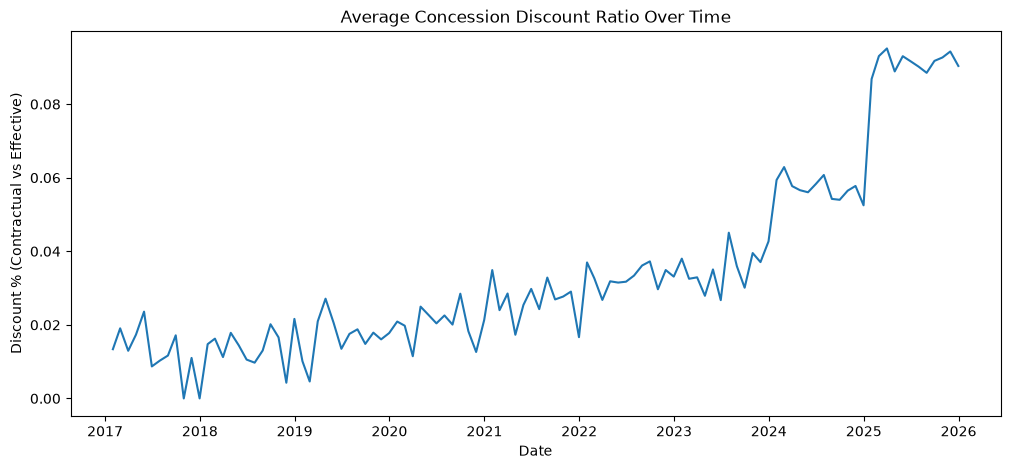

In [27]:
lease_df['sLeaseFrom'] = pd.to_datetime(lease_df['sLeaseFrom'])
lease_df['Concession_Discount_Ratio'] = (lease_df['sRent'] - lease_df['sRentEffective']) / lease_df['sRent']

trend_df = lease_df.set_index('sLeaseFrom').resample('ME')['Concession_Discount_Ratio'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x='sLeaseFrom', y='Concession_Discount_Ratio')
plt.title('Average Concession Discount Ratio Over Time')
plt.ylabel('Discount % (Contractual vs Effective)')
plt.xlabel('Date')
plt.show()


## 3. Retention Drivers (The Concession Cliff)
We will flag which leases received which concessions, and see how that impacts the probability of renewal (`sRenewal`).

In [28]:
# Pivot concessions by hUnit and Date
conc_df['sDateFrom'] = pd.to_datetime(conc_df['sDateFrom'])

conc_sorted = conc_df.sort_values('sDateFrom')
lease_sorted = lease_df.sort_values('sLeaseFrom')

# Create Dummy columns for concession types
conc_dummies = pd.get_dummies(conc_sorted['sChargeCode'], prefix='Conc')
conc_processed = pd.concat([conc_sorted[['hUnit', 'sDateFrom']], conc_dummies], axis=1)

# Aggregate concessions that happen on the same date
conc_processed = conc_processed.groupby(['hUnit', 'sDateFrom']).max().reset_index()

# IMPORTANT: merge_asof requires the right dataframe to be explicitly sorted by the exact merge key
conc_processed = conc_processed.sort_values('sDateFrom')

# Merge onto lease history (finding concessions given just prior to or during the lease start)
merged_df = pd.merge_asof(
    lease_sorted,
    conc_processed,
    by='hUnit',
    left_on='sLeaseFrom',
    right_on='sDateFrom',
    direction='backward',
    tolerance=pd.Timedelta('365D') # Only match concessions given within the last year
)

merged_df.head()


,hProperty,hUnit,hBuilding,sPropCode,sUnitCode,sBuilding,sCity,sState,sAddr1,sLatitude,...,Concession_Discount_Ratio,sDateFrom,Conc_Freeothe,Conc_Indem,Conc_PromoPay,Conc_Referenc,Conc_freeappl,Conc_freelock,Conc_freepark,Conc_freerent
0,105,5234,13,stelz1,0607,Saint-Elzear,Laval,Quebec,3830 Boul. Saint-Elzear O.,45.57129,...,0.028639,2017-01-01,False,False,False,False,False,False,True,False
1,105,5263,13,stelz1,0909,Saint-Elzear,Laval,Quebec,3830 Boul. Saint-Elzear O.,45.57129,...,0.000000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,105,5299,13,stelz1,1409,Saint-Elzear,Laval,Quebec,3830 Boul. Saint-Elzear O.,45.57129,...,0.000000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,105,5305,13,stelz1,1506,Saint-Elzear,Laval,Quebec,3830 Boul. Saint-Elzear O.,45.57129,...,0.029134,2017-01-01,False,False,False,False,False,False,True,False
4,105,5214,13,stelz1,0405,Saint-Elzear,Laval,Quebec,3830 Boul. Saint-Elzear O.,45.57129,...,0.000000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Modeling Retention (Is_Renewal)
We build a classification model to see the Feature Importance of specific concessions on retention.

              precision    recall  f1-score   support

           0       0.62      0.75      0.68       495
           1       0.52      0.37      0.43       366

    accuracy                           0.59       861
   macro avg       0.57      0.56      0.55       861
weighted avg       0.58      0.59      0.57       861



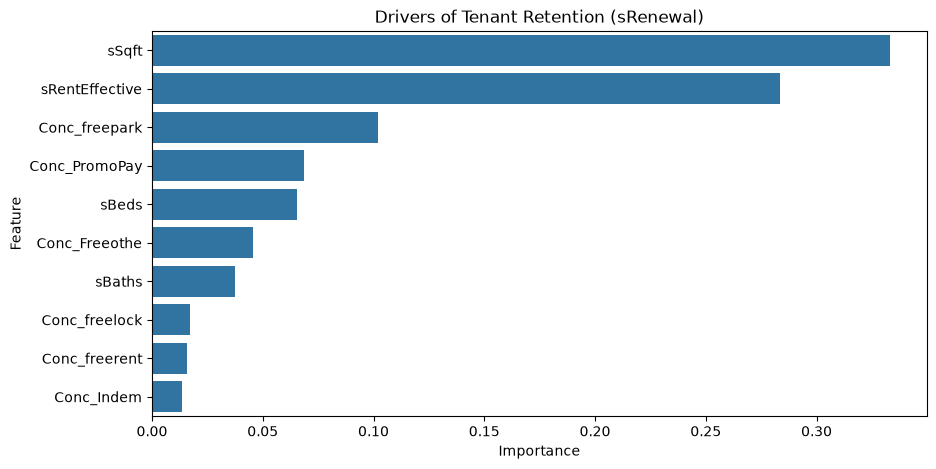

In [29]:
# Fill NaNs for leases that had no concessions
concession_cols = [c for c in merged_df.columns if c.startswith('Conc_')]
merged_df[concession_cols] = merged_df[concession_cols].fillna(0)

# For this simple exploration, we predict sRenewal based on unit traits and concessions.
features = ['sBeds', 'sBaths', 'sSqft', 'sRentEffective'] + concession_cols

X = merged_df[features].copy().fillna(0)
y = merged_df['sRenewal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature Importance
imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_classifier.feature_importances_})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature')
plt.title('Drivers of Tenant Retention (sRenewal)')
plt.show()


## Concession Popularity by Building\n\nDifferent properties might rely on different incentive structures depending on their market positioning (e.g. brand new lease-ups might offer 'Months Free', whereas older buildings might offer 'Cash Rebates' or 'Parking Promos'). Let's visualize the distribution of concession types across the different buildings.

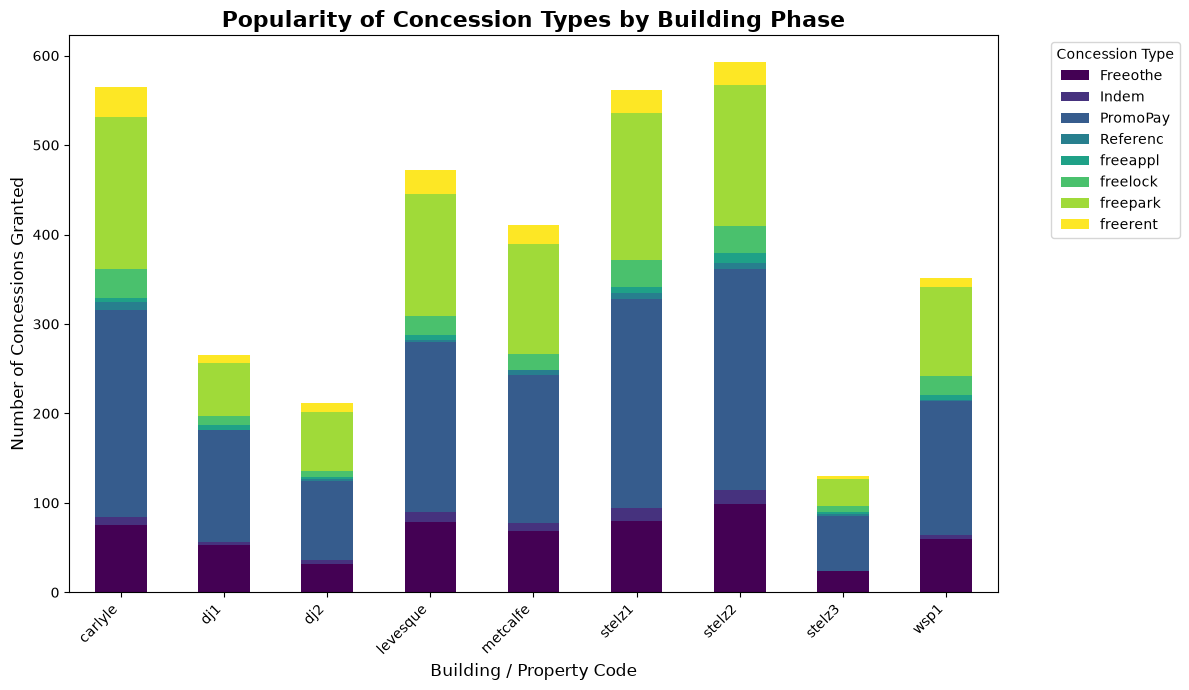

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
data_dir = 'data/'
conc_df = pd.read_csv(data_dir + 'equinoxe_concessions.csv')
conc_df.columns = conc_df.columns.str.strip()

# 2. Calculate frequency of each concession type per building (using sPropCode to separate Saint-Elzear phases)
conc_counts = conc_df.groupby(['sPropCode', 'sChargeCode']).size().unstack(fill_value=0)

# 3. Plotting
plt.figure(figsize=(12, 7))
conc_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Popularity of Concession Types by Building Phase', fontsize=16, fontweight='bold')
plt.xlabel('Building / Property Code', fontsize=12)
plt.ylabel('Number of Concessions Granted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Concession Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
